## OptimESM: NEMO Pipeline Diagnostics

In [6]:
import glob
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import cartopy.feature as cfeature

/g100/home/userexternal/otooth00/.conda/envs/env_optimesm/lib/python3.13/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [56]:
filedir="/g100_work/optim_IAC/research/noc/otooth/OptimESM/data/UKESM1-2-LL/esm-piControl"
filepath=f"{filedir}/r1i1p1f1/Omon/mlotst/gn/v20241002/mlotst_Omon_UKESM1-2-LL_esm-piControl_r1i1p1f1_gn_*.nc"

time_coder = xr.coders.CFDatetimeCoder(time_unit="s")
ds_gridT = xr.open_mfdataset(filepath, decode_times=time_coder, data_vars='all')
ds_gridT

<xarray.Dataset> Size: 39GB
Dimensions:             (time: 4812, bnds: 2, j: 330, i: 360, vertices: 4)
Coordinates:
  * time                (time) object 38kB 2100-01-16 00:00:00 ... 2500-12-16...
  * j                   (j) int32 1kB 0 1 2 3 4 5 6 ... 324 325 326 327 328 329
  * i                   (i) int32 1kB 0 1 2 3 4 5 6 ... 354 355 356 357 358 359
    latitude            (j, i) float64 950kB dask.array<chunksize=(330, 360), meta=np.ndarray>
    longitude           (j, i) float64 950kB dask.array<chunksize=(330, 360), meta=np.ndarray>
Dimensions without coordinates: bnds, vertices
Data variables:
    time_bnds           (time, bnds) object 77kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    vertices_latitude   (time, j, i, vertices) float64 18GB dask.array<chunksize=(600, 330, 360, 4), meta=np.ndarray>
    vertices_longitude  (time, j, i, vertices) float64 18GB dask.array<chunksize=(600, 330, 360, 4), meta=np.ndarray>
    mlotst              (time, j, i) float32 2GB dask.array<chunksize=(1, 330, 360), meta=np.ndarray>
Attributes: (12/39)
    Conventions:           CF-1.7 CMIP-6.2
    activity_id:           TerraFIRMA
    branch_method:         no parent
    creation_date:         2024-06-18T10:54:44Z
    cv_version:            GCModelDev v0.0.17
    data_specs_version:    GCModelDev v0.0.17
    ...                    ...
    variable_id:           mlotst
    variable_name:         mlotst
    variant_label:         r1i1p1f1
    license:               GCModelDev model data is licensed under the Open G...
    cmor_version:          3.7.3
    tracking_id:           GCMODELDEV/26332c1a-baeb-464e-a943-023579378a2b

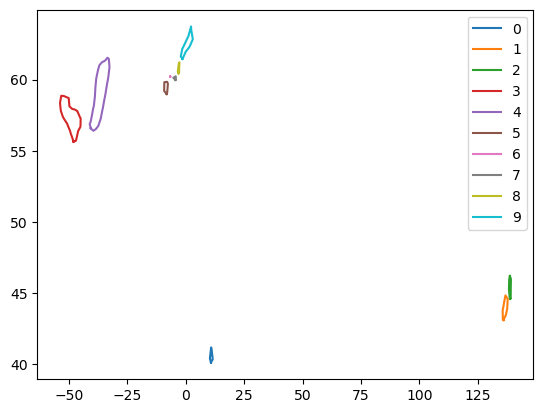

In [45]:
mlotst_mmean = ds_gridT['mlotst'].sel(time=ds_gridT['time'].dt.month.isin([3])).mean(dim='time')
cs = plt.contour(ds_gridT['longitude'], ds_gridT['latitude'], mlotst_mmean,
                 levels=[500]
                 )

plt.figure()
for n in range(len(cs.allsegs[0]))[:10]:
    ml_poly = cs.allsegs[0][n]
    lon_ml_poly = np.array([coord[0] for coord in ml_poly], dtype=np.float32)
    lat_ml_poly = np.array([coord[1] for coord in ml_poly], dtype=np.float32)
    plt.plot(lon_ml_poly, lat_ml_poly, label=str(n))

plt.legend()

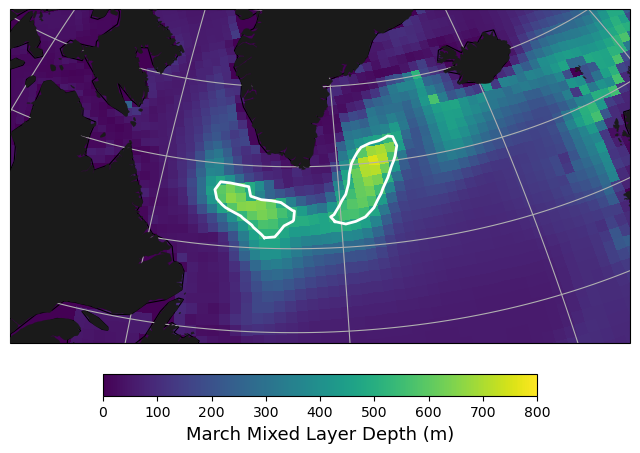

In [48]:
# Create a figure with an orthographic (globe) projection:
fig = plt.figure(figsize=(8, 8))
proj = ccrs.Orthographic(central_longitude=-45, central_latitude=40)  # change center
ax = plt.axes(projection=proj)
ax.set_extent([-70, -15, 47, 68])
ax.coastlines(resolution='110m', linewidth=0.8)
ax.add_feature(cfeature.LAND, facecolor='0.1', edgecolor='0.1', linewidth=0.2, zorder=4)
ax.gridlines(draw_labels=False, dms=True, x_inline=False, y_inline=False)

# Plot the DataArray. Use transform=ccrs.PlateCarree since data coords are lon/lat
c = plt.pcolormesh(ds_gridT['longitude'], ds_gridT['latitude'], mlotst_mmean,
                   cmap='viridis', shading='auto', zorder=1, transform=ccrs.PlateCarree(),
                   vmin=0, vmax=800
                    )

# 500-m time-mean March Mixed Layer Depth Polygon:
ml_poly = cs.allsegs[0][3]
lon_ml_poly = np.array([coord[0] for coord in ml_poly], dtype=np.float32)
lat_ml_poly = np.array([coord[1] for coord in ml_poly], dtype=np.float32)
# Overlay the Labrador Sea nest boundary & 500m MLD contour:
plt.plot(lon_ml_poly, lat_ml_poly, color='w', lw=2, transform=ccrs.PlateCarree(), zorder=5)

# 500-m time-mean March Mixed Layer Depth Polygon:
ml_poly = cs.allsegs[0][4]
lon_ml_poly = np.array([coord[0] for coord in ml_poly], dtype=np.float32)
lat_ml_poly = np.array([coord[1] for coord in ml_poly], dtype=np.float32)
# Overlay the Irminger Sea nest boundary & 500m MLD contour:
plt.plot(lon_ml_poly, lat_ml_poly, color='w', lw=2, transform=ccrs.PlateCarree(), zorder=5)

# Add colorbar and title
cb = plt.colorbar(c, orientation="horizontal", pad=0.05, shrink=0.7)
cb.set_label("March Mixed Layer Depth (m)", fontsize=13)

# NEMODataTree

In [58]:
from nemo_cookbook import NEMODataTree

In [57]:
ds_domain_cfg = xr.open_dataset("/g100_work/optim_IAC/research/noc/otooth/OptimESM/data/UKESM1-2-LL/Ofx/eORCA1_domain_cfg_UKESM1.nc")
if "z" in ds_domain_cfg.dims:
    ds_domain_cfg = ds_domain_cfg.rename({"z": "nav_lev"})
# Add dimension coordinates:
ds_domain_cfg = ds_domain_cfg.assign_coords({'nav_lev': np.arange(ds_domain_cfg['nav_lev'].size),
                                             'y': np.arange(ds_domain_cfg['y'].size),
                                             'x': np.arange(ds_domain_cfg['x'].size)
                                            })


# Update CMORISED dimensions to NEMO standard names:
grid_suffix = "t"
update_dims = {"i": "x", "j": "y", "time": "time_counter"}
if "lev" in ds_gridT.dims:
    update_dims["lev"] = f"depth{grid_suffix}"
ds_gridT = ds_gridT.rename(update_dims)

In [59]:
datasets = {"parent": {"domain": ds_domain_cfg, "gridT": ds_gridT}}

# Create a NEMODataTree using a zonally periodic, north folding (defined on F-points) parent domain:
nemo = NEMODataTree.from_datasets(datasets=datasets, iperio=True, nftype="F")
nemo

<xarray.DataTree>
Group: /
│   Dimensions:       (time_counter: 4812, bnds: 2)
│   Coordinates:
│     * time_counter  (time_counter) object 38kB 2100-01-16 00:00:00 ... 2500-12-...
│   Dimensions without coordinates: bnds
│   Data variables:
│       time_bnds     (time_counter, bnds) object 77kB dask.array<chunksize=(1, 2), meta=np.ndarray>
│   Attributes:
│       nftype:   F
│       iperio:   True
├── Group: /gridT
│       Dimensions:             (time_counter: 4812, bnds: 2, j: 330, i: 360,
│                                vertices: 4, k: 75)
│       Coordinates:
│         * j                   (j) int64 3kB 1 2 3 4 5 6 7 ... 325 326 327 328 329 330
│         * i                   (i) int64 3kB 1 2 3 4 5 6 7 ... 355 356 357 358 359 360
│         * k                   (k) int64 600B 1 2 3 4 5 6 7 8 ... 69 70 71 72 73 74 75
│           latitude            (j, i) float64 950kB dask.array<chunksize=(330, 360), meta=np.ndarray>
│           longitude           (j, i) float64 950kB dask.array<chunksize=(330, 360), meta=np.ndarray>
│           gphit               (j, i) float64 950kB ...
│           glamt               (j, i) float64 950kB ...
│       Dimensions without coordinates: bnds, vertices
│       Data variables:
│           time_bnds           (time_counter, bnds) object 77kB dask.array<chunksize=(1, 2), meta=np.ndarray>
│           vertices_latitude   (time_counter, j, i, vertices) float64 18GB dask.array<chunksize=(600, 330, 360, 4), meta=np.ndarray>
│           vertices_longitude  (time_counter, j, i, vertices) float64 18GB dask.array<chunksize=(600, 330, 360, 4), meta=np.ndarray>
│           mlotst              (time_counter, j, i) float32 2GB dask.array<chunksize=(1, 330, 360), meta=np.ndarray>
│           e1t                 (j, i) float64 950kB ...
│           e2t                 (j, i) float64 950kB ...
│           tmask               (k, j, i) float64 71MB 0.0 0.0 0.0 0.0 ... nan nan nan
│           tmaskutil           (j, i) float64 950kB 0.0 0.0 0.0 0.0 ... nan nan nan nan
│       Attributes:
│           nftype:   F
│           iperio:   True
├── Group: /gridU
│       Dimensions:       (j: 330, i: 360, k: 75)
│       Coordinates:
│         * j             (j) int64 3kB 1 2 3 4 5 6 7 8 ... 324 325 326 327 328 329 330
│         * i             (i) float64 3kB 1.5 2.5 3.5 4.5 ... 357.5 358.5 359.5 360.5
│         * k             (k) int64 600B 1 2 3 4 5 6 7 8 9 ... 68 69 70 71 72 73 74 75
│           gphiu         (j, i) float64 950kB ...
│           glamu         (j, i) float64 950kB ...
│       Data variables:
│           e1u           (j, i) float64 950kB ...
│           e2u           (j, i) float64 950kB ...
│           umask         (k, j, i) float64 71MB 0.0 0.0 0.0 0.0 0.0 ... nan nan nan nan
│           umaskutil     (j, i) float64 950kB 0.0 0.0 0.0 0.0 0.0 ... nan nan nan nan
│       Attributes:
│           nftype:   F
│           iperio:   True
├── Group: /gridV
│       Dimensions:       (j: 330, i: 360, k: 75)
│       Coordinates:
│         * j             (j) float64 3kB 1.5 2.5 3.5 4.5 ... 327.5 328.5 329.5 330.5
│         * i             (i) int64 3kB 1 2 3 4 5 6 7 8 ... 354 355 356 357 358 359 360
│         * k             (k) int64 600B 1 2 3 4 5 6 7 8 9 ... 68 69 70 71 72 73 74 75
│           gphiv         (j, i) float64 950kB ...
│           glamv         (j, i) float64 950kB ...
│       Data variables:
│           e1v           (j, i) float64 950kB ...
│           e2v           (j, i) float64 950kB ...
│           vmask         (k, j, i) float64 71MB 0.0 0.0 0.0 0.0 0.0 ... nan nan nan nan
│           vmaskutil     (j, i) float64 950kB 0.0 0.0 0.0 0.0 0.0 ... nan nan nan nan
│       Attributes:
│           nftype:   F
│           iperio:   True
├── Group: /gridW
│       Dimensions:       (j: 330, i: 360, k: 75)
│       Coordinates:
│         * j             (j) int64 3kB 1 2 3 4 5 6 7 8 ... 324 325 326 327 328 329 330
│         * i             (i) int64 3kB 1 2 3 4 5 6 7 8 ... 354 355 356 357 358 

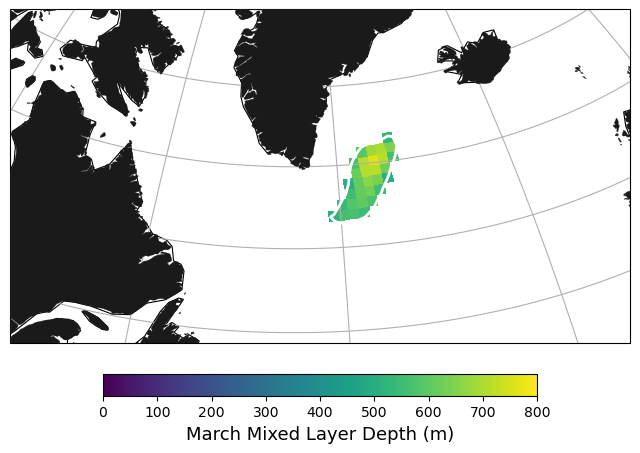

In [64]:
mask_IrmSea = nemo.mask_with_polygon(grid="gridT", lon_poly=lon_ml_poly, lat_poly=lat_ml_poly)

# Create a figure with an orthographic (globe) projection:
fig = plt.figure(figsize=(8, 8))
proj = ccrs.Orthographic(central_longitude=-45, central_latitude=40)  # change center
ax = plt.axes(projection=proj)
ax.set_extent([-70, -15, 47, 68])
ax.coastlines(resolution='110m', linewidth=0.8)
ax.add_feature(cfeature.LAND, facecolor='0.1', edgecolor='0.1', linewidth=0.2, zorder=4)
ax.gridlines(draw_labels=False, dms=True, x_inline=False, y_inline=False)

# Plot the DataArray. Use transform=ccrs.PlateCarree since data coords are lon/lat
c = plt.pcolormesh(ds_gridT['longitude'], ds_gridT['latitude'], mlotst_mmean.where(mask_IrmSea),
                   cmap='viridis', shading='auto', zorder=1, transform=ccrs.PlateCarree(),
                   vmin=0, vmax=800
                    )

# 500-m time-mean March Mixed Layer Depth Polygon:
ml_poly = cs.allsegs[0][3]
lon_ml_poly = np.array([coord[0] for coord in ml_poly], dtype=np.float32)
lat_ml_poly = np.array([coord[1] for coord in ml_poly], dtype=np.float32)
# Overlay the Labrador Sea nest boundary & 500m MLD contour:
plt.plot(lon_ml_poly, lat_ml_poly, color='w', lw=2, transform=ccrs.PlateCarree(), zorder=5)

# 500-m time-mean March Mixed Layer Depth Polygon:
ml_poly = cs.allsegs[0][4]
lon_ml_poly = np.array([coord[0] for coord in ml_poly], dtype=np.float32)
lat_ml_poly = np.array([coord[1] for coord in ml_poly], dtype=np.float32)
# Overlay the Irminger Sea nest boundary & 500m MLD contour:
plt.plot(lon_ml_poly, lat_ml_poly, color='w', lw=2, transform=ccrs.PlateCarree(), zorder=5)

# Add colorbar and title
cb = plt.colorbar(c, orientation="horizontal", pad=0.05, shrink=0.7)
cb.set_label("March Mixed Layer Depth (m)", fontsize=13)